In [2]:
import pandas as pd

csv_file= pd.read_csv('Electronic_sales_Sep2023-Sep2024.csv')

# Задание 1 (синтаксис)

# Для каждого покупателя получите таблицу со столбцами:
#  • preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);
#  • total_spent - сумма всех трат;
#  • addons_spent - сумма на дополнительные услуги и аксессуары;
#  • orders_count - число заказов.
 
#  Отсортируйте по total_spent по убыванию и выведите топ-10.

# Пример вывода (формат; числа зависят от датасета):

#    customer_id  preferred_payment  total_spent  addons_spent  orders_count
#  0         C042     Credit Card              15420.50        890.00             7
#  1         C018     PayPal                     14810.00        450.00             5
#  2         C103     Debit Card               13990.25       1200.00             6
#  ...

# Пограничные случаи:

# • Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
#  • Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
#  • Покупатель без доп. услуг/аксессуаров - addons_spent = 0.
#  • Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.


# print(csv_file.head())
#Пограничные случаи
# Два метода оплаты с одинаковой частотой - по умолчанию метод value counts сортирует элементы при одинаковых значениях в алфавитном порядке, в этом порядке я оставил выборку
# Пропуски в сумме или методе оплаты - удалил такие заказы

csv_file = csv_file.dropna(subset=['Payment Method','Total Price'])
result = csv_file.groupby('Customer ID', as_index=False).agg(
    preferred_payment=('Payment Method', lambda x: x.value_counts().index[0]),
    total_spent=('Total Price','sum'),
    addons_spent=('Add-on Total','sum'),
    orders_count=('Customer ID', 'count')
    
    
)

result.columns = [col.lower().replace(' ', '_') for col in result.columns]


result['addons_spent'] = result['addons_spent'].fillna(0)

sorted_res = result.sort_values('total_spent',ascending=False).reset_index(drop=True)


print(sorted_res.head(10))




   customer_id preferred_payment  total_spent  addons_spent  orders_count
0        16357     Bank Transfer     34563.70        495.19             7
1        16863            PayPal     33035.92        486.17             5
2        13813       Credit Card     31830.16        268.64             5
3        11476            PayPal     31077.61        301.59             5
4        12276     Bank Transfer     30961.18        329.07             6
5        13635       Credit Card     30260.36        480.73             5
6        12749       Credit Card     29394.56        619.43             5
7        15399            PayPal     29084.88        305.39             3
8        12319     Bank Transfer     27352.32        226.38             3
9        19996            PayPal     27296.78        432.12             6


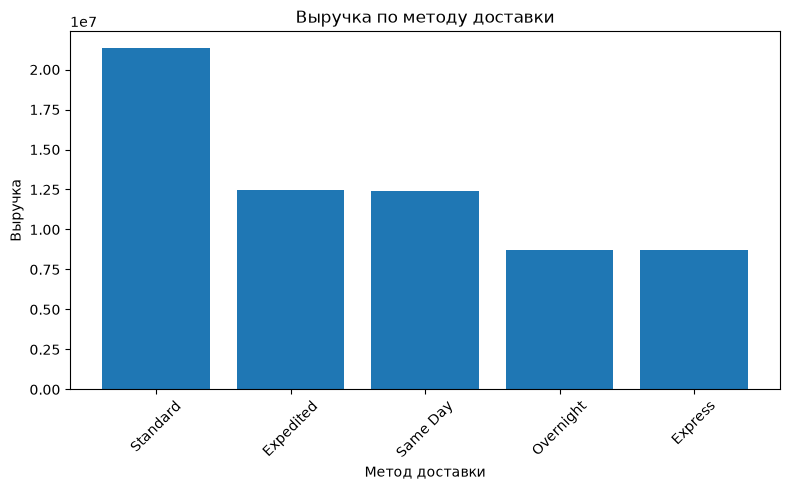

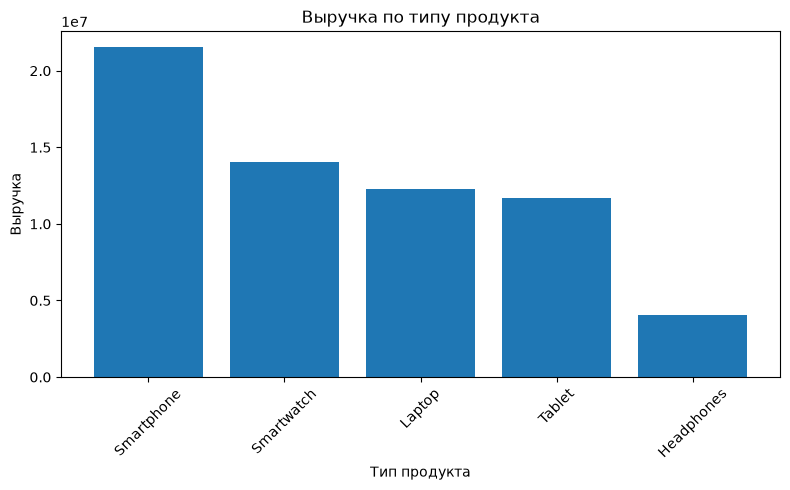

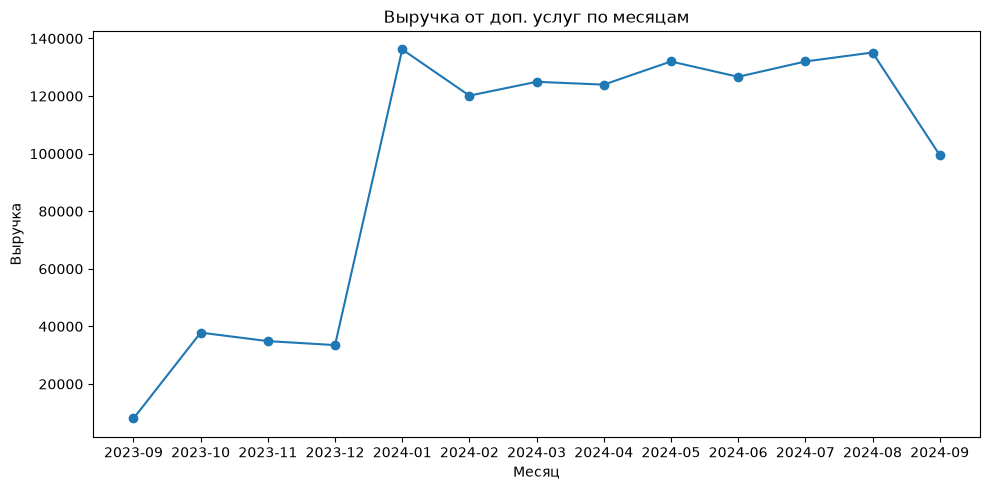

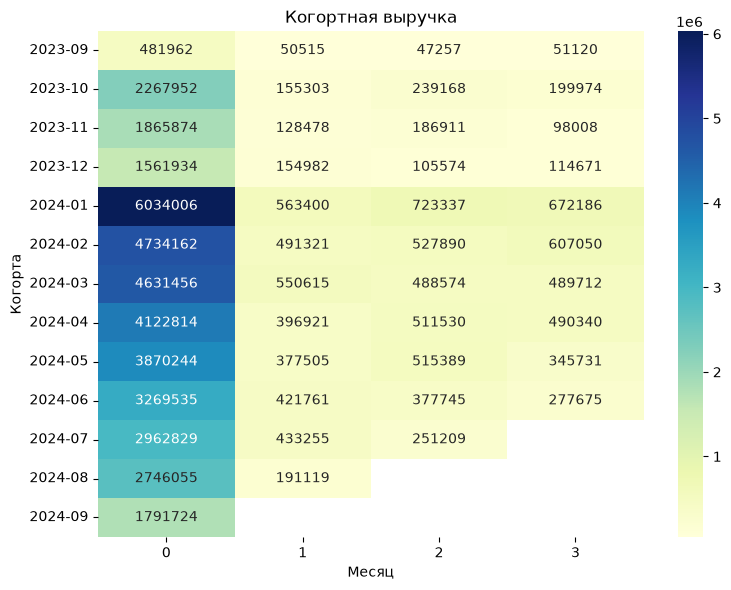

In [ ]:
# Задание 2 (повышенная сложность)

# Постройте пайплайн на Pandas (без циклов по строкам):
 
#  1. Очистка: типы дат, пропуски, аномалии (отрицательные суммы / нулевые цены) - кратко опишите, что отфильтровали.
#  2. Метрики:
#     • доход по методу доставки;
#     • доход по типу продукта;
#     • доход по доп. услугам: по месяцам и по кварталам;
#     • cohort-анализ: когорта = месяц первого заказа покупателя; для каждой когорты - выручка и число покупателей в следующие 0, 1, 2, 3 месяца.
#  3. Визуализация (минимум 3 графика): bar (доставка / тип продукта), line (доп. услуги по месяцам), heatmap когортной матрицы выручки.
#  4. Выводы: несколько предложений по графикам. (?необязательно)
 
#  Дополнительно: оформите шаги 1–2 как функции clean(df) → df и build_metrics(df) → dict[str, DataFrame].

#1) отфильтровал аномалии: если total_price <= 0 или quantity <= 0 или unit_price <= 0 м, то то строка пропускается.
# если 'customer_id','product_type', 'sku','order_status','payment_method','unit_price','quantity','purchase_date','total_price' пустые - пропускается
# некорректные даты в purchase date помечаются как пустые

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def clean(csv_file_2):
    csv_file_2 = csv_file_2.copy()
    csv_file_2.columns = [col.lower().replace(' ', '_') for col in csv_file_2.columns]
    csv_file_2['purchase_date'] = pd.to_datetime(csv_file_2['purchase_date'], errors='coerce')
    
    csv_file_2 = csv_file_2.dropna(subset=['customer_id','product_type', 'sku','order_status','payment_method','unit_price','quantity','purchase_date','total_price'])
    
    csv_file_2 = csv_file_2[(csv_file_2['total_price'] > 0) & (csv_file_2['quantity'] > 0) & (csv_file_2['unit_price'] > 0)]

    #метрика доход по доп. услугам: по месяцам и по кварталам;
    #месяца
    csv_file_2['month'] = csv_file_2['purchase_date'].dt.strftime('%Y-%m')
    csv_file_2['quart'] = csv_file_2['purchase_date'].dt.to_period('Q').astype(str)
    return csv_file_2
###################

def build_metrics(csv_file_2):
    metrics = {}
    csv_file_2 = csv_file_2.copy()

    #метрика доход по методу доставки
    metrics['revenue_by_shipping'] = csv_file_2.groupby(['shipping_type'], as_index=False).agg(
        revenue=('total_price','sum')
    ).rename(columns={'shipping_type':'shipping_method'})

    metrics['revenue_by_shipping'] = metrics['revenue_by_shipping'].sort_values(by='revenue', ascending=False, ignore_index=True)
    # print(metrics['revenue_by_shipping'].head())

    #метрика  доход по типу продукта
    metrics['revenue_by_type'] = csv_file_2.groupby(['product_type'], as_index=False).agg(
        revenue=('total_price', 'sum')
    )
    metrics['revenue_by_type'] = metrics['revenue_by_type'].sort_values(by='revenue', ascending=False, ignore_index=True)
    # print(metrics['revenue_by_type'].head())

    metrics['addons_by_month'] = csv_file_2.groupby(['month'], as_index=False).agg(
        addons_revenue=('add-on_total', 'sum')
    )
    metrics['addons_by_month'] = metrics['addons_by_month'].sort_values(by='addons_revenue', ascending=False, ignore_index=True)
    # print(metrics['addons_by_month'].head())

    metrics['addons_by_quart'] = csv_file_2.groupby(['quart'], as_index=False).agg(
        addons_revenue=('add-on_total', 'sum')
    )
    metrics['addons_by_quart'] = metrics['addons_by_quart'].sort_values(by='addons_revenue', ascending=False, ignore_index=True)

    csv_file_2['order_month'] = csv_file_2['purchase_date'].dt.to_period('M')
    csv_file_2['cohort_month'] = csv_file_2.groupby('customer_id')['order_month'].transform('min')

    csv_file_2['period'] = (csv_file_2['order_month'] - csv_file_2['cohort_month']).apply(lambda x: x.n)

    needle = csv_file_2[csv_file_2['period'] <= 3]

    #когорта по выручке
    cohort_rev = needle.pivot_table(
        values='total_price',
        index='cohort_month',
        columns='period',
        aggfunc='sum'
    )
    metrics['cohort_revenue'] = cohort_rev

    #когорта по количеству пользователей
    cohort_customers = needle.pivot_table(
        values='customer_id',
        index='cohort_month',
        columns='period',
        aggfunc='nunique'
    )
    metrics['cohort_customers'] = cohort_customers

    metrics['cohort_customers'].index = metrics['cohort_customers'].index.astype(str)
    metrics['cohort_revenue'].index = metrics['cohort_revenue'].index.astype(str)

    metrics['cohort_revenue']   = metrics['cohort_revenue'].reindex(columns=[0,1,2,3])
    metrics['cohort_customers'] = metrics['cohort_customers'].reindex(columns=[0,1,2,3])

    metrics['addons_by_month'] = metrics['addons_by_month'].sort_values('month', ignore_index=True)
    metrics['cohort_revenue'] = metrics['cohort_revenue'].sort_index()

    return metrics


dff = pd.read_csv('Electronic_sales_Sep2023-Sep2024.csv')

csv_file_3 = clean(dff)
metrics = build_metrics(csv_file_3)





# print(csv_file_2.head())

#график доставки
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metrics['revenue_by_shipping']['shipping_method'],
       metrics['revenue_by_shipping']['revenue'])
ax.set_title('Выручка по методу доставки')
ax.set_xlabel('Метод доставки')
ax.set_ylabel('Выручка')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#график по типу продукта
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(metrics['revenue_by_type']['product_type'],
       metrics['revenue_by_type']['revenue'])
ax.set_title('Выручка по типу продукта')
ax.set_xlabel('Тип продукта')
ax.set_ylabel('Выручка')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#график выручки
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics['addons_by_month']['month'], metrics['addons_by_month']['addons_revenue'], marker='o')
ax.set_title('Выручка от доп. услуг по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка')
plt.tight_layout()
plt.show()

#график когорты

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['cohort_revenue'], annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title('Когортная выручка')
ax.set_xlabel('Месяц')
ax.set_ylabel('Когорта')
plt.tight_layout()
plt.show()